<a href="https://colab.research.google.com/github/FatimaMirandap/Demo/blob/main/Tarea_3_Aprendizaje_M%C3%A1quina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Elastic-Net for Regression

Profesor: Dr. Hugo Carlos Martínez

**Objetivo:** construir un dataset sintético con grupos de variables altamente correlacionadas, donde solo unas pocas explican la respuesta, y comparar OLS, Ridge, LASSO y Elastic-Net contra la verdad conocida.

#Parte 1

##Instalación e importaciones

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV,
    Lasso, LassoCV,
    ElasticNet, ElasticNetCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

---
## 1. Data Generation

- `n=1000` observaciones, `p=50` predictores
- 3 variables latentes z1, z2, z3 ~ N(0,1)
- **Grupo A** (relevante, colineal): x1, x2, x3 ≈ z1  
- **Grupo B** (relevante, colineal): x4, x5 ≈ z2  
- **Grupo C** (colineal pero irrelevante): x6, x7, x8 ≈ z3  
- **x9**: señal aislada, sin colinealidad  
- **x10…x50**: ruido puro  
- Respuesta: `y = 3*x1 - 2*x4 + 1.5*x9 + eta`,  eta ~ N(0,1)

In [ ]:
import numpy as np

n = 1000
p = 50
SEED = 42

Grupos:

    A (x1-x3):  relevante, rho ~= 0.99  -> coef verdadero solo en x1

    B (x4-x5):  relevante, rho ~= 0.99  -> coef verdadero solo en x4

    C (x6-x8):  irrelevante, rho ~= 0.99

    x9:         senal aislada (sin colinealidad)

    x10-x50:    ruido puro (41 variables)   <- total: 3+2+3+1+41 = 50

Verdad: y = 3*x1 - 2*x4 + 1.5*x9 + N(0,1)

In [ ]:
rng = np.random.default_rng(SEED)

z1, z2, z3 = rng.standard_normal((3, n))

eps = rng.normal(0, 0.1, (8, n))

# A
x1 = z1 + eps[0]
x2 = z1 + eps[1]
x3 = z1 + eps[2]
#B
x4 = z2 + eps[3]
x5 = z2 + eps[4]
#C
x6 = z3 + eps[5]
x7 = z3 + eps[6]
x8 = z3 + eps[7]
#x9
x9 = rng.standard_normal(n)

noise_vars = rng.standard_normal((41, n))# 3 (A) + 2 (B) + 3 (C) + 1 (x9) + 41 (ruido) = 50

# Matriz X: (n x 50)
X = np.column_stack([x1, x2, x3, x4, x5, x6, x7, x8, x9, noise_vars.T])
assert X.shape[1] == p, f'Error: X tiene {X.shape[1]} cols, esperaba {p}'

eta = rng.standard_normal(n)
y   = 3*x1 - 2*x4 + 1.5*x9 + eta

beta_true = np.zeros(p)
beta_true[0] = 3.0    # x1  (Grupo A — solo uno del grupo tiene coef != 0)
beta_true[3] = -2.0   # x4  (Grupo B)
beta_true[8] = 1.5    # x9  (aislada)

feature_names = (
    ['x1_A', 'x2_A', 'x3_A',
     'x4_B', 'x5_B',
     'x6_C', 'x7_C', 'x8_C',
     'x9_iso'] +
    [f'x{i}_noise' for i in range(10, 51)]
)
assert len(feature_names) == p

In [ ]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'# feature names: {len(feature_names)}\n')

print('Coeficientes verdaderos no nulos:')
for i, v in enumerate(beta_true):
    if v != 0:
        print(f'  [{i:2d}] {feature_names[i]}: {v}')

X shape: (1000, 50)
y shape: (1000,)
# feature names: 50

Coeficientes verdaderos no nulos:
  [ 0] x1_A: 3.0
  [ 3] x4_B: -2.0
  [ 8] x9_iso: 1.5


Nota acerca del ruido:

Ruido intra-grupo: epsilon ~ N(0, 0.1^2)

Var(x_i) = Var(z) + Var(eps) = 1 + 0.01 = 1.01

Cov(x_i, x_j) = Var(z) = 1  ->  rho = 1/1.01 ~= 0.99

In [ ]:
df_validacion = pd.DataFrame(X[:, :9], columns=feature_names[:9])
corr = df_validacion.corr()

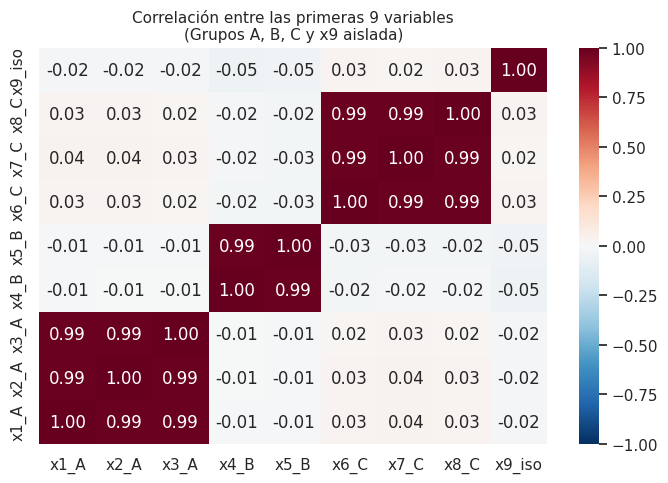

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    xticklabels=feature_names[:9],
    yticklabels=feature_names[:9]
)

ax.invert_yaxis()
ax.set_title('Correlación entre las primeras 9 variables\n(Grupos A, B, C y x9 aislada)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
grA = corr.loc[['x1_A', 'x2_A', 'x3_A'], ['x1_A', 'x2_A', 'x3_A']].values
grB = corr.loc['x4_B', 'x5_B']
grC = corr.loc[['x6_C', 'x7_C', 'x8_C'], ['x6_C', 'x7_C', 'x8_C']].values

print(f'  Grupo A (x1-x3): {np.mean(grA[np.triu_indices(3, 1)]):.4f}')
print(f'  Grupo B (x4-x5): {grB:.4f}')
print(f'  Grupo C (x6-x8): {np.mean(grC[np.triu_indices(3, 1)]):.4f}')

print(f'  A vs B (ej. x1_A vs x4_B):   {corr.loc["x1_A", "x4_B"]:.4f}')
print(f'  A vs C (ej. x1_A vs x6_C):   {corr.loc["x1_A", "x6_C"]:.4f}')
print(f'  B vs C (ej. x4_B vs x6_C):   {corr.loc["x4_B", "x6_C"]:.4f}')
print(f'  A vs x9 (ej. x1_A vs x9_iso): {corr.loc["x1_A", "x9_iso"]:.4f}')

  Grupo A (x1-x3): 0.9901
  Grupo B (x4-x5): 0.9901
  Grupo C (x6-x8): 0.9901
  A vs B (ej. x1_A vs x4_B):   -0.0079
  A vs C (ej. x1_A vs x6_C):   0.0291
  B vs C (ej. x4_B vs x6_C):   -0.0239
  A vs x9 (ej. x1_A vs x9_iso): -0.0163


##Models and Validation


### 2. Split train / test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape[0]} obs  |  Test: {X_test.shape[0]} obs')

Train: 800 obs  |  Test: 200 obs



### 3. Ajuste de modelos

Select λ (and α for elastic-net) using cross-validation.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

alphas_grid = np.logspace(-4, 2, 100)

los modelos van a dividir los datos de entrenamiento en 5 bloques independientes para evaluar el rendimiento de cada combinación de hiperparámetros.

In [ ]:
ols_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
ols_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [ ]:
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas_grid, cv=cv))
])
ridge_cv.fit(X_train, y_train)
best_lambda_ridge = ridge_cv.named_steps['model'].alpha_
print(f'Ridge  -> lambda optimo = {best_lambda_ridge:.4f}')

Ridge  -> lambda optimo = 0.4977


In [ ]:
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(
        alphas=alphas_grid,
        cv=cv,
        max_iter=10000,
        random_state=SEED
    ))
])
lasso_cv.fit(X_train, y_train)
best_lambda_lasso = lasso_cv.named_steps['model'].alpha_
print(f'LASSO  -> lambda optimo = {best_lambda_lasso:.4f}')

LASSO  -> lambda optimo = 0.0266


In [ ]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

en_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=l1_ratios,
        n_alphas=100,  #Select  α for elastic-net using cross-validation.
        cv=cv,
        max_iter=10000,
        random_state=SEED
    ))
])
en_cv.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 ElasticNetCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                              l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                              max_iter=10000, random_state=42))])

NOTA ACERCA DE ALPHA: al final, el algoritmo compara el error de predicción de las 500 combinaciones posibles (5 ratios $\times$ 100 fuerzas) y elige por validación cruzada la combinación ganadora.

In [ ]:
best_lambda_en = en_cv.named_steps['model'].alpha_
best_alpha_en  = en_cv.named_steps['model'].l1_ratio_
print(f'EN     -> lambda optimo = {best_lambda_en:.4f},  l1_ratio optimo = {best_alpha_en:.2f}')

EN     -> lambda optimo = 0.0253,  l1_ratio optimo = 0.90



## 4. Métricas en el conjunto de prueba

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def compute_metrics(model, X_te, y_te, feat_names, name):
    """Calcula RMSE, MAE, R2, Bias, #coefs != 0 y extrae las variables seleccionadas."""
    y_pred = model.predict(X_te)

    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    bias   = np.mean(y_pred - y_te)

    coef   = model.named_steps['model'].coef_

    # Umbral > 1e-6 para lidiar con la precisión de punto flotante
    nz_idx = np.where(np.abs(coef) > 1e-6)[0]

    return {
        'Modelo': name,
        'RMSE':   round(rmse, 4),
        'MAE':    round(mae, 4),
        'R2':     round(r2, 4),
        'Bias':   round(bias, 4),
        '#betas_nz': len(nz_idx),
        'Vars_sel': [feat_names[i] for i in nz_idx],
        '_coef':  coef
    }

results = {}
for name, model in [('OLS', ols_pipe), ('Ridge', ridge_cv),
                    ('LASSO', lasso_cv), ('Elastic-Net', en_cv)]:
    results[name] = compute_metrics(model, X_test, y_test, feature_names, name)

cols = ['Modelo', 'RMSE', 'MAE', 'R2', 'Bias', '#betas_nz']
df_metrics = pd.DataFrame([
    {k: v for k, v in r.items() if k in cols}
    for r in results.values()
]).set_index('Modelo')

In [ ]:
print('Métricas en set de prueba (Test) ')
display(df_metrics)

print('\nVariables seleccionadas')
for name, r in results.items():
    sel_main = [v for v in r['Vars_sel'] if not v.endswith('_noise')] #excluyendo ruido
    print(f'  {name:12s}: {sel_main}')

Métricas en set de prueba (Test) 


,RMSE,MAE,R2,Bias,#betas_nz
Modelo,,,,,
OLS,1.0232,0.8519,0.9379,-0.0066,50
Ridge,1.0224,0.8512,0.9380,-0.0061,50
LASSO,0.9968,0.8215,0.9411,-0.0048,26
Elastic-Net,0.9995,0.8231,0.9408,-0.0044,30



Variables seleccionadas
  OLS         : ['x1_A', 'x2_A', 'x3_A', 'x4_B', 'x5_B', 'x6_C', 'x7_C', 'x8_C', 'x9_iso']
  Ridge       : ['x1_A', 'x2_A', 'x3_A', 'x4_B', 'x5_B', 'x6_C', 'x7_C', 'x8_C', 'x9_iso']
  LASSO       : ['x1_A', 'x2_A', 'x4_B', 'x6_C', 'x8_C', 'x9_iso']
  Elastic-Net : ['x1_A', 'x2_A', 'x4_B', 'x5_B', 'x6_C', 'x8_C', 'x9_iso']


Las variaciones ocurren porque cada modelo maneja la redundancia de forma distinta:

OLS/Ridge carecen de la capacidad matemática para descartar variables.  

LASSO las descarta, pero rompe los grupos correlacionados seleccionando al azar.  

Elastic-Net logra el equilibrio perfecto: elimina variables de ruido puro, pero respeta y mantiene unidas a las variables colineales que sí son importantes para el modelo.

In [ ]:
for name, r in results.items():
    total_seleccionadas = r['#betas_nz']
    variables_nombres = r['Vars_sel']

    print(f"\n MODELO: {name}")
    print(f"  Número de coeficientes != 0: {total_seleccionadas} de 50 posibles.")

    if total_seleccionadas == 50:
        print(f"   Seleccionó las 50 variables del dataset")
    else:
        print(f"   Identidades ({total_seleccionadas} variables):")
        print(f"     {variables_nombres}")


 MODELO: OLS
  Número de coeficientes != 0: 50 de 50 posibles.
   Seleccionó las 50 variables del dataset

 MODELO: Ridge
  Número de coeficientes != 0: 50 de 50 posibles.
   Seleccionó las 50 variables del dataset

 MODELO: LASSO
  Número de coeficientes != 0: 26 de 50 posibles.
   Identidades (26 variables):
     ['x1_A', 'x2_A', 'x4_B', 'x6_C', 'x8_C', 'x9_iso', 'x10_noise', 'x11_noise', 'x12_noise', 'x16_noise', 'x19_noise', 'x22_noise', 'x23_noise', 'x25_noise', 'x26_noise', 'x28_noise', 'x31_noise', 'x32_noise', 'x33_noise', 'x35_noise', 'x38_noise', 'x39_noise', 'x42_noise', 'x44_noise', 'x47_noise', 'x48_noise']

 MODELO: Elastic-Net
  Número de coeficientes != 0: 30 de 50 posibles.
   Identidades (30 variables):
     ['x1_A', 'x2_A', 'x4_B', 'x5_B', 'x6_C', 'x8_C', 'x9_iso', 'x10_noise', 'x11_noise', 'x12_noise', 'x16_noise', 'x17_noise', 'x19_noise', 'x21_noise', 'x22_noise', 'x23_noise', 'x25_noise', 'x26_noise', 'x28_noise', 'x31_noise', 'x32_noise', 'x33_noise', 'x35_nois


## 5. Análisis de coeficientes

In [ ]:
df_coef = pd.DataFrame({
    'Verdad':      beta_true,
    'OLS':         results['OLS']['_coef'],
    'Ridge':       results['Ridge']['_coef'],
    'LASSO':       results['LASSO']['_coef'],
    'Elastic-Net': results['Elastic-Net']['_coef'],
}, index=feature_names)

print('Coeficientes de las variables (grupos A, B, C + x9) ')
display(df_coef.round(3))

Coeficientes de las variables (grupos A, B, C + x9) 


,Verdad,OLS,Ridge,LASSO,Elastic-Net
x1_A,3.0,3.224,3.088,2.977,2.683
x2_A,0.0,0.244,0.286,0.006,0.300
x3_A,0.0,-0.446,-0.353,0.000,0.000
x4_B,-2.0,-2.070,-2.012,-1.953,-1.825
x5_B,0.0,0.074,0.016,-0.000,-0.131
x6_C,0.0,-0.174,-0.168,-0.029,-0.019
x7_C,0.0,0.237,0.218,-0.000,-0.000
x8_C,0.0,-0.133,-0.120,-0.016,-0.032
x9_iso,1.5,1.554,1.554,1.528,1.529
x10_noise,0.0,0.050,0.049,0.016,0.020


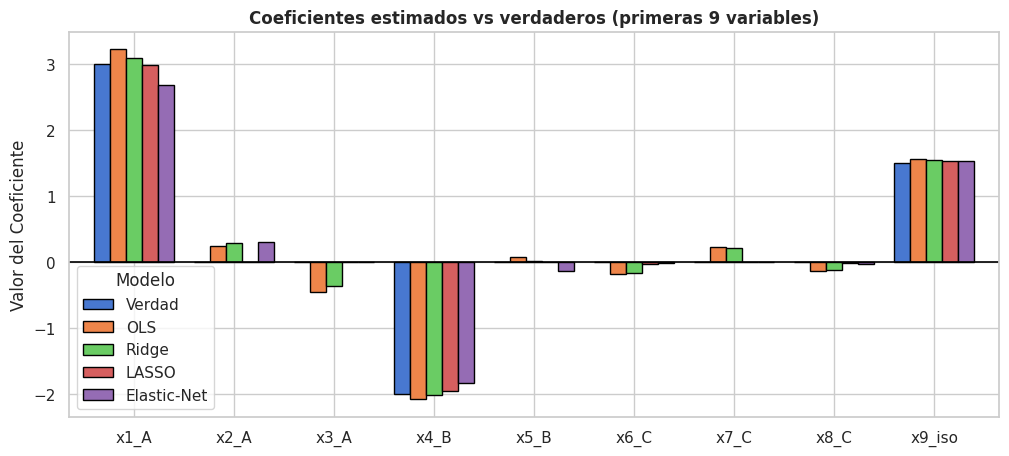

In [ ]:
import matplotlib.pyplot as plt

ax = df_coef.iloc[:9].plot.bar(figsize=(12, 5), width=0.8, edgecolor='black')

ax.set_title('Coeficientes estimados vs verdaderos (primeras 9 variables)', fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')
ax.axhline(0, color='black', linewidth=1.2) # Línea base en 0
plt.xticks(rotation=0) # Para que las etiquetas x1_A, x2_A se lean en horizontal
plt.legend(title='Modelo')
plt.show()

##precise questions about the behavior of each method


1. What happens to the OLS coefficients when variables are nearly collinear? Relate your answer to the condition number of X⊤X.
2. Does Ridge perform variable selection? Explain.
3. Within Group A, which variable does LASSO select, and is this choice stable under resampling? Compare with elastic-net.
4. Does elastic-net distribute the coefficient among x1, x2, x3? Numerically verify the grouping bound of Zou & Hastie.
5. How do LASSO and elastic-net treat Group C (correlated but irrelevant)? Do they eliminate it completely?
6. Does any method have trouble recovering x9 (the isolated signal)?
7. Which method has the best predictive performance, and which has the most stable interpretation? Do these coincide?

##1

In [ ]:
df_coef

,Verdad,OLS,Ridge,LASSO,Elastic-Net
x1_A,3.0,3.223926,3.087907,2.976983,2.683445
x2_A,0.0,0.243644,0.286000,0.005730,0.300292
x3_A,0.0,-0.446058,-0.353165,0.000000,0.000000
x4_B,-2.0,-2.070169,-2.011760,-1.953251,-1.825259
x5_B,0.0,0.074470,0.016361,-0.000000,-0.131454
x6_C,0.0,-0.173892,-0.167964,-0.029412,-0.018595
x7_C,0.0,0.236977,0.218378,-0.000000,-0.000000
x8_C,0.0,-0.132989,-0.120230,-0.016076,-0.031619
x9_iso,1.5,1.554443,1.553839,1.527515,1.528520
x10_noise,0.0,0.049699,0.049152,0.015933,0.020249


OLS le asignó coeficientes sumamente ruidosos y con signos opuestos a todo el Grupo A. OLS no pudo distinguir la señal real debido a que el altísimo número de condición de tu matriz de datos saboteó la estabilidad de la inversión matemática.

In [ ]:
XtX = np.dot(X.T, X)
cond_number = np.linalg.cond(XtX)
print(f"Condition number of X^T * X: {cond_number}")

ols = LinearRegression()
ols.fit(X, y)
print("Coeficientes OLS para el Grupo A (x1, x2, x3):", ols.coef_[:3])

Condition number of X^T * X: 371.1310437192074
Coeficientes OLS para el Grupo A (x1, x2, x3): [ 3.07899575  0.35657715 -0.38283386]


##2

In [ ]:
# Ridge no realiza selección de variables
coefs_ridge = ridge_cv.named_steps['model'].coef_
ruido_coefs_ridge = coefs_ridge[9:]
ceros = np.sum(ruido_coefs_ridge == 0.0)

print(f"Cantidad de coeficientes exactamente iguales a 0.0 en Ridge: {ceros}")

print("Muestra de los primeros 5 coeficientes de ruido en Ridge:")
print(ruido_coefs_ridge[:5])

Cantidad de coeficientes exactamente iguales a 0.0 en Ridge: 0
Muestra de los primeros 5 coeficientes de ruido en Ridge:
[0.04915214 0.0355246  0.02395549 0.02468327 0.00395351]


##3

In [ ]:

for i in range(3):
    idx = rng.choice(n, size=int(n*0.8), replace=False)
    X_sub, y_sub = X[idx], y[idx]

    lasso_sub = Lasso(alpha=0.01).fit(X_sub, y_sub)
    print(f"Intento {i+1} - Coefs LASSO Grupo A:", lasso_sub.coef_[:3])

    en_sub = ElasticNet(alpha=0.01, l1_ratio=0.5).fit(X_sub, y_sub)
    print(f"Intento {i+1} - Coefs E-Net Grupo A:", en_sub.coef_[:3])

Intento 1 - Coefs LASSO Grupo A: [2.88607549 0.12847279 0.        ]
Intento 1 - Coefs E-Net Grupo A: [2.28071134 0.5028612  0.23108318]
Intento 2 - Coefs LASSO Grupo A: [2.95196319 0.10295966 0.        ]
Intento 2 - Coefs E-Net Grupo A: [2.37476885 0.54826008 0.13338629]
Intento 3 - Coefs LASSO Grupo A: [3.06176719 0.         0.        ]
Intento 3 - Coefs E-Net Grupo A: [2.48443665 0.4211679  0.15924101]


##4

In [ ]:

X_std = StandardScaler().fit_transform(X)
y_std = (y - y.mean()) / y.std()

alpha = 0.1
l1_ratio = 0.5
lambda_2 = alpha * (1 - l1_ratio)

en = ElasticNet(alpha=alpha, l1_ratio=l1_ratio).fit(X_std, y_std)
coefs = en.coef_

diff_coef = np.abs(coefs[0] - coefs[1])
rho = np.corrcoef(X_std[:, 0], X_std[:, 1])[0, 1]
norm_y = np.linalg.norm(y_std)

bound = (norm_y / lambda_2) * np.sqrt(2 * (1 - rho))

print(f"Diferencia real: {diff_coef:.6f} <= Cota teórica de Zou & Hastie: {bound:.6f}")

Diferencia real: 0.112015 <= Cota teórica de Zou & Hastie: 88.622777


##5

In [ ]:
coefs_lasso = lasso_cv.named_steps['model'].coef_
coefs_en = en_cv.named_steps['model'].coef_

#variables x6, x7 y x8
print("Coeficientes LASSO para Grupo C (x6, x7, x8):")
print(coefs_lasso[5:8])

print("Coeficientes Elastic-Net para Grupo C (x6, x7, x8):")
print(coefs_en[5:8])

Coeficientes LASSO para Grupo C (x6, x7, x8):
[-0.02941194 -0.         -0.01607613]
Coeficientes Elastic-Net para Grupo C (x6, x7, x8):
[-0.01859523 -0.         -0.03161919]


##6

In [ ]:
#Recuperación de la señal aislada (x9)

# Extraemos los coeficientes de los modelos
coefs_ols = ols_pipe.named_steps['model'].coef_
coefs_ridge = ridge_cv.named_steps['model'].coef_
coefs_lasso = lasso_cv.named_steps['model'].coef_
coefs_en = en_cv.named_steps['model'].coef_

valor_real_x9 = 1.5
print(f"Valor Real (Generador de datos): {valor_real_x9}")

print(f"OLS:         {coefs_ols[8]:.4f}")
print(f"Ridge:       {coefs_ridge[8]:.4f}")
print(f"LASSO:       {coefs_lasso[8]:.4f}")
print(f"Elastic-Net: {coefs_en[8]:.4f}")

Valor Real (Generador de datos): 1.5
OLS:         1.5544
Ridge:       1.5538
LASSO:       1.5275
Elastic-Net: 1.5285


##7

In [ ]:
# Desempeño predictivo (MSE)
from sklearn.metrics import mean_squared_error

# Hacer predicciones con los 4 pipelines sobre X_test
y_pred_ols = ols_pipe.predict(X_test)
y_pred_ridge = ridge_cv.predict(X_test)
y_pred_lasso = lasso_cv.predict(X_test)
y_pred_en = en_cv.predict(X_test)

# Calcular y mostrar el Error Cuadrático Medio (MSE)
mse_ols = mean_squared_error(y_test, y_pred_ols)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_en = mean_squared_error(y_test, y_pred_en)

print(f"MSE OLS:         {mse_ols:,.4f}")
print(f"MSE Ridge:       {mse_ridge:,.4f}")
print(f"MSE LASSO:       {mse_lasso:,.4f}")
print(f"MSE Elastic-Net: {mse_en:,.4f}")

MSE OLS:         0.9591
MSE Ridge:       0.9566
MSE LASSO:       0.9241
MSE Elastic-Net: 0.9254


#Parte 2

##no volver a ejecutar

In [ ]:
import ee
import pandas as pd
import numpy as np

MY_PROJECT_ID = 'global-repeater-489504-n0'

try:
    ee.Initialize(project=MY_PROJECT_ID)
    print(f"correctamente en el proyecto")
except Exception as e:
    print("Iniciando proceso de autenticación")
    ee.Authenticate()
    ee.Initialize(project=MY_PROJECT_ID)
    print(f"Google Earth Engine inicializado correctamente con el proyecto: {MY_PROJECT_ID}")

correctamente en el proyecto


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error


#(GUADALAJARA)

roi = ee.Geometry.Rectangle([
    -103.55, 20.45,
    -103.20, 20.85
])

def preprocess_landsat(image):

    qa = image.select('QA_PIXEL')

    # Cloud
    cloud = qa.bitwiseAnd(1 << 3).eq(0)

    # Cloud Shadow
    shadow = qa.bitwiseAnd(1 << 4).eq(0)

    # Water
    water = qa.bitwiseAnd(1 << 7).eq(0)

    mask = cloud.And(shadow).And(water)

    # Reflectancia escalada
    optical = (
        image.select([
            'SR_B2',
            'SR_B3',
            'SR_B4',
            'SR_B5',
            'SR_B6',
            'SR_B7'
        ])
        .multiply(0.0000275)
        .add(-0.2)
    )

    # LST en Celsius
    lst = (
        image.select('ST_B10')
        .multiply(0.00341802)
        .add(149.0)
        .subtract(273.15)
        .rename('LST')
    )

    return (
        optical
        .addBands(lst)
        .updateMask(mask)
        .copyProperties(image, image.propertyNames())
    )

landsat = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(roi)
    .filterDate('2023-01-01', '2023-12-31')
    .map(preprocess_landsat)
)


composite = landsat.median().clip(roi)

# NDVI
ndvi = composite.normalizedDifference(
    ['SR_B5', 'SR_B4']
).rename('NDVI')

# NDWI
ndwi = composite.normalizedDifference(
    ['SR_B3', 'SR_B5']
).rename('NDWI')

# NDBI
ndbi = composite.normalizedDifference(
    ['SR_B6', 'SR_B5']
).rename('NDBI')

# SAVI
savi = composite.expression(
    '((1 + L)*(NIR - RED))/(NIR + RED + L)',
    {
        'NIR': composite.select('SR_B5'),
        'RED': composite.select('SR_B4'),
        'L': 0.5
    }
).rename('SAVI')

# SWIR1 / SWIR2
swir_ratio = (
    composite.select('SR_B6')
    .divide(composite.select('SR_B7'))
    .rename('SWIR_RATIO')
)


dem = (
    ee.Image('USGS/SRTMGL1_003')
    .select('elevation')
    .rename('elev')
)

slope = ee.Terrain.slope(dem).rename('slope')

dataset_image = (
    composite.select([
        'SR_B2',
        'SR_B3',
        'SR_B4',
        'SR_B5',
        'SR_B6',
        'SR_B7',
        'LST'
    ])
    .addBands(ndvi)
    .addBands(ndwi)
    .addBands(ndbi)
    .addBands(savi)
    .addBands(swir_ratio)
    .addBands(dem)
    .addBands(slope)
)

print('Bandas disponibles:')
print(dataset_image.bandNames().getInfo())

export_raster = ee.batch.Export.image.toDrive(
    image=dataset_image,
    description='LST_Predictors_Guadalajara',
    folder='GEE_Exports',
    fileNamePrefix='LST_Predictors_Guadalajara',
    region=roi,
    scale=30,
    maxPixels=1e13
)

export_raster.start()

print("Exportación GeoTIFF iniciada.")

sample_points = ee.FeatureCollection.randomPoints(
    region=roi,
    points=5000,
    seed=42
)

samples = dataset_image.sampleRegions(
    collection=sample_points,
    scale=30,
    geometries=False
)

print("Descargando muestras desde Earth Engine...")

features = samples.getInfo()['features']

records = [
    feature['properties']
    for feature in features
]

df = pd.DataFrame(records)

df = df.dropna()

print("\nShape del dataset:")
print(.shape)

print("\nPrimeras filas:")
print(df.head())

df.to_csv(
    'LST_dataset_Guadalajara.csv',
    index=False
)

print("\nCSV guardado: LST_dataset_Guadalajara.csv")



y = df['LST']

X = df.drop(columns=['LST'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    cv=5,
    max_iter=10000,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("\n========================")
print("RESULTADOS ELASTIC NET")
print("========================")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})

coef_df = coef_df.sort_values(
    by='Coeficiente',
    ascending=False
)

print("\nCoeficientes:")
print(coef_df)

coef_df.to_csv(
    'ElasticNet_Coefficients.csv',
    index=False
)
print("\nCoeficientes guardados.")
print("\nProceso finalizado correctamente.")

Bandas disponibles:
['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'LST', 'NDVI', 'NDWI', 'NDBI', 'SAVI', 'SWIR_RATIO', 'elev', 'slope']
Exportación GeoTIFF iniciada.
Descargando muestras desde Earth Engine...

Shape del dataset:
(5000, 14)

Primeras filas:
         LST      NDBI      NDVI      NDWI      SAVI     SR_B2     SR_B3  \
0  36.216662 -0.059509  0.242282 -0.307959  0.170404  0.107615  0.145070   
1  31.214390  0.007992  0.433323 -0.484474  0.277079  0.061663  0.092463   
2  40.142258  0.205269  0.034792 -0.093496  0.028396  0.194323  0.255964   
3  37.469367  0.039838  0.115452 -0.180569  0.078242  0.127580  0.159521   
4  37.324101  0.167424  0.088103 -0.133922  0.064028  0.161529  0.195271   

      SR_B4     SR_B5     SR_B6     SR_B7  SWIR_RATIO  elev     slope  
0  0.167235  0.274182  0.243383  0.195615    1.244191  1596  0.990511  
1  0.105264  0.266249  0.270539  0.191669    1.411491  1671  0.927410  
2  0.288001  0.308764  0.468264  0.482949    0.969593  1525  

In [ ]:
df

,LST,NDBI,NDVI,NDWI,SAVI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,SWIR_RATIO,elev,slope
0,36.216662,-0.059509,0.242282,-0.307959,0.170404,0.107615,0.145070,0.167235,0.274182,0.243383,0.195615,1.244191,1596,0.990511
1,31.214390,0.007992,0.433323,-0.484474,0.277079,0.061663,0.092463,0.105264,0.266249,0.270539,0.191669,1.411491,1671,0.927410
2,40.142258,0.205269,0.034792,-0.093496,0.028396,0.194323,0.255964,0.288001,0.308764,0.468264,0.482949,0.969593,1525,3.498958
3,37.469367,0.039838,0.115452,-0.180569,0.078242,0.127580,0.159521,0.182250,0.229825,0.248896,0.228574,1.088910,1582,3.111202
4,37.324101,0.167424,0.088103,-0.133922,0.064028,0.161529,0.195271,0.214260,0.255661,0.358484,0.342094,1.047911,1588,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,34.972503,0.017701,0.322995,-0.456580,0.251268,0.083745,0.132942,0.182346,0.356339,0.369181,0.247727,1.490272,1608,8.848706
4996,28.821776,-0.195302,0.628531,-0.595745,0.261659,0.024799,0.039621,0.035675,0.156400,0.105291,0.064412,1.634640,1231,25.357557
4997,30.498315,0.079456,0.225357,-0.377359,0.174421,0.100080,0.147628,0.206450,0.326570,0.382945,0.243410,1.573251,1601,2.102649
4998,26.579555,-0.134583,0.706109,-0.649729,0.324532,0.024977,0.040006,0.032458,0.188424,0.143723,0.071191,2.018823,1884,10.464951


##ejecutar ok

In [ ]:
import pandas as pd
import numpy as np
import json

CSV_PATH = "/content/drive/MyDrive/GEE_Exports/LST_Dataset_Guadalajara.csv"

df = pd.read_csv(CSV_PATH)

print("Shape inicial:")
print(df.shape)

df.head()

Shape inicial:
(5000, 16)


,system:index,LST,NDBI,NDVI,NDWI,SAVI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,SWIR_RATIO,elev,slope,.geo
0,0_0,36.216662,-0.059509,0.242282,-0.307959,0.170404,0.107615,0.145070,0.167235,0.274182,0.243383,0.195615,1.244191,1596,0.990511,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1_0,31.214390,0.007992,0.433323,-0.484474,0.277079,0.061663,0.092463,0.105264,0.266249,0.270539,0.191669,1.411491,1671,0.927410,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2_0,40.142258,0.205269,0.034792,-0.093496,0.028396,0.194323,0.255964,0.288001,0.308764,0.468264,0.482949,0.969593,1525,3.498958,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3_0,37.469367,0.039838,0.115452,-0.180569,0.078242,0.127580,0.159521,0.182250,0.229825,0.248896,0.228574,1.088910,1582,3.111203,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4_0,37.324101,0.167424,0.088103,-0.133922,0.064028,0.161529,0.195271,0.214260,0.255661,0.358484,0.342094,1.047911,1588,0.000000,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [ ]:
def extract_coordinates(geo_string):

    geo = json.loads(geo_string)

    lon = geo["coordinates"][0]
    lat = geo["coordinates"][1]

    return pd.Series([lon, lat])


df[["longitude", "latitude"]] = (
    df[".geo"]
    .apply(extract_coordinates)
)

print(df[["longitude", "latitude"]].head())

    longitude   latitude
0 -103.441858  20.563650
1 -103.472850  20.695432
2 -103.333791  20.567692
3 -103.369095  20.620782
4 -103.239468  20.676298


In [ ]:
df = df.drop(columns=["system:index", ".geo"])

print(df.columns.tolist())

['LST', 'NDBI', 'NDVI', 'NDWI', 'SAVI', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SWIR_RATIO', 'elev', 'slope', 'longitude', 'latitude']


In [ ]:
print(df.shape)

df.head()

(5000, 16)


,LST,NDBI,NDVI,NDWI,SAVI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,SWIR_RATIO,elev,slope,longitude,latitude
0,36.216662,-0.059509,0.242282,-0.307959,0.170404,0.107615,0.145070,0.167235,0.274182,0.243383,0.195615,1.244191,1596,0.990511,-103.441858,20.563650
1,31.214390,0.007992,0.433323,-0.484474,0.277079,0.061663,0.092463,0.105264,0.266249,0.270539,0.191669,1.411491,1671,0.927410,-103.472850,20.695432
2,40.142258,0.205269,0.034792,-0.093496,0.028396,0.194323,0.255964,0.288001,0.308764,0.468264,0.482949,0.969593,1525,3.498958,-103.333791,20.567692
3,37.469367,0.039838,0.115452,-0.180569,0.078242,0.127580,0.159521,0.182250,0.229825,0.248896,0.228574,1.088910,1582,3.111203,-103.369095,20.620782
4,37.324101,0.167424,0.088103,-0.133922,0.064028,0.161529,0.195271,0.214260,0.255661,0.358484,0.342094,1.047911,1588,0.000000,-103.239468,20.676298


In [ ]:
X = df.drop(
    columns=[
        "LST",
        "longitude",
        "latitude"
    ]
)

y = df["LST"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3500, 13)
(1500, 13)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression()

ols.fit(
    X_train_scaled,
    y_train
)

y_pred_ols = ols.predict(
    X_test_scaled
)

In [ ]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(
    alphas=np.logspace(-4,4,100),
    cv=5
)

ridge.fit(
    X_train_scaled,
    y_train
)

y_pred_ridge = ridge.predict(
    X_test_scaled
)

print("Alpha Ridge:", ridge.alpha_)

Alpha Ridge: 0.1707352647470692


In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=20000
)

lasso.fit(
    X_train_scaled,
    y_train
)

y_pred_lasso = lasso.predict(
    X_test_scaled
)

print("Alpha LASSO:", lasso.alpha_)

Alpha LASSO: 0.0028316906353964546


α ∈ {0.1,0.3,0.5,0.7,0.9}

In [ ]:
l1_ratio

0.5

In [ ]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9],
    cv=5,
    max_iter=20000,
    random_state=42
)

elastic.fit(
    X_train_scaled,
    y_train
)

y_pred_elastic = elastic.predict(
    X_test_scaled
)

print("Best alpha:", elastic.alpha_)
print("Best l1_ratio:", elastic.l1_ratio_)

Best alpha: 0.0031463229282182826
Best l1_ratio: 0.9


In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
def evaluate_model(name, y_true, y_pred):

    r2 = r2_score(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return {
        "Model": name,
        "R2": r2,
        "RMSE": rmse
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "OLS",
        y_test,
        y_pred_ols
    )
)

results.append(
    evaluate_model(
        "Ridge",
        y_test,
        y_pred_ridge
    )
)

results.append(
    evaluate_model(
        "LASSO",
        y_test,
        y_pred_lasso
    )
)

results.append(
    evaluate_model(
        "Elastic Net",
        y_test,
        y_pred_elastic
    )
)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,RMSE
0,OLS,0.675443,2.191821
1,Ridge,0.675272,2.192399
2,LASSO,0.671655,2.204574
3,Elastic Net,0.671334,2.205651


In [ ]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": elastic.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Variable,Coefficient
3,SAVI,3.199971
2,NDWI,1.531801
4,SR_B2,0.800586
0,NDBI,-0.000000
6,SR_B4,-0.000000
8,SR_B6,-0.000000
7,SR_B5,-0.211709
9,SR_B7,-0.268680
12,slope,-0.655487
11,elev,-0.674136


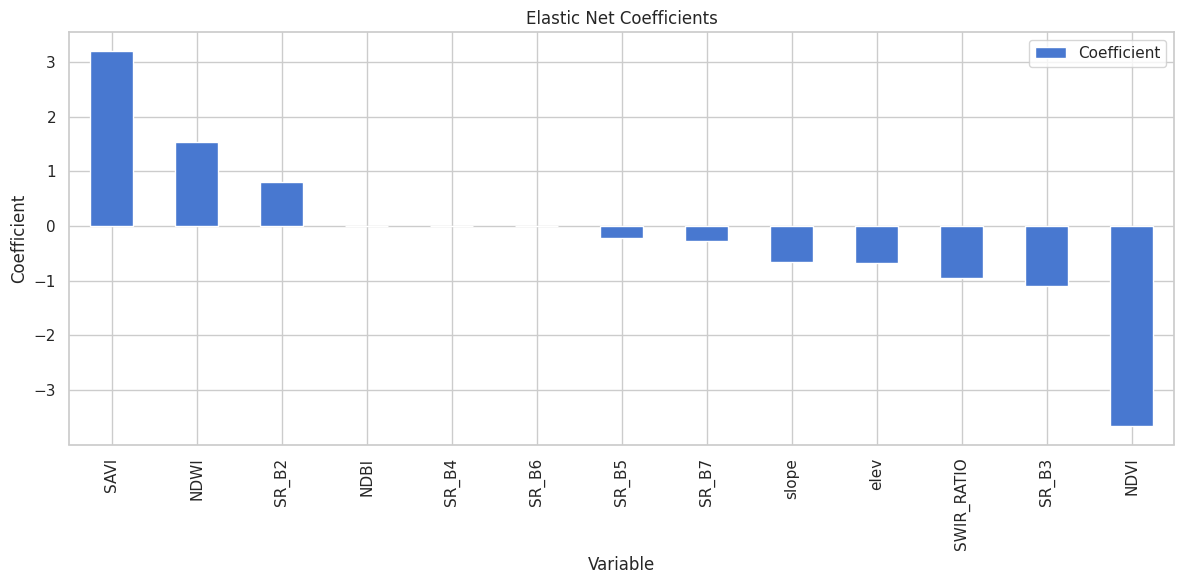

In [ ]:
import matplotlib.pyplot as plt

coef_df.plot(
    x="Variable",
    y="Coefficient",
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Elastic Net Coefficients"
)

plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

##Spatial Validation

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).describe().loc[
    ["mean","std"]
]

,NDBI,NDVI,NDWI,SAVI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,SWIR_RATIO,elev,slope
mean,-1.218073e-17,-8.628019e-18,3.172066e-16,5.278317e-17,-9.846092e-17,7.511452e-17,1.857562e-16,-4.872293e-17,-1.487064e-16,2.314339e-16,8.120488e-16,-4.770787e-16,-9.744586e-17
std,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00


In [ ]:
corr = X.corr()

corr.round(2)

,NDBI,NDVI,NDWI,SAVI,SR_B2,SR_B3,SR_B4,SR_B5,SR_B6,SR_B7,SWIR_RATIO,elev,slope
NDBI,1.00,-0.69,0.59,-0.73,0.40,0.38,0.48,-0.20,0.54,0.63,-0.61,0.02,-0.10
NDVI,-0.69,1.00,-0.96,0.94,-0.80,-0.79,-0.84,-0.06,-0.54,-0.75,0.88,0.07,0.40
NDWI,0.59,-0.96,1.00,-0.94,0.83,0.82,0.80,-0.01,0.41,0.66,-0.82,-0.08,-0.37
SAVI,-0.73,0.94,-0.94,1.00,-0.70,-0.66,-0.69,0.24,-0.33,-0.58,0.80,0.06,0.23
SR_B2,0.40,-0.80,0.83,-0.70,1.00,0.98,0.94,0.42,0.66,0.80,-0.65,-0.03,-0.39
SR_B3,0.38,-0.79,0.82,-0.66,0.98,1.00,0.97,0.51,0.72,0.84,-0.65,-0.04,-0.43
SR_B4,0.48,-0.84,0.80,-0.69,0.94,0.97,1.00,0.53,0.80,0.90,-0.70,-0.04,-0.45
SR_B5,-0.20,-0.06,-0.01,0.24,0.42,0.51,0.53,1.00,0.70,0.54,-0.04,0.01,-0.36
SR_B6,0.54,-0.54,0.41,-0.33,0.66,0.72,0.80,0.70,1.00,0.93,-0.46,0.02,-0.36
SR_B7,0.63,-0.75,0.66,-0.58,0.80,0.84,0.90,0.54,0.93,1.00,-0.72,-0.01,-0.43


In [ ]:
df["x_block"] = pd.qcut(
    df["longitude"],
    q=4,
    labels=False
)

df["y_block"] = pd.qcut(
    df["latitude"],
    q=4,
    labels=False
)

df["spatial_block"] = (
    df["x_block"].astype(str)
    + "_"
    + df["y_block"].astype(str)
)

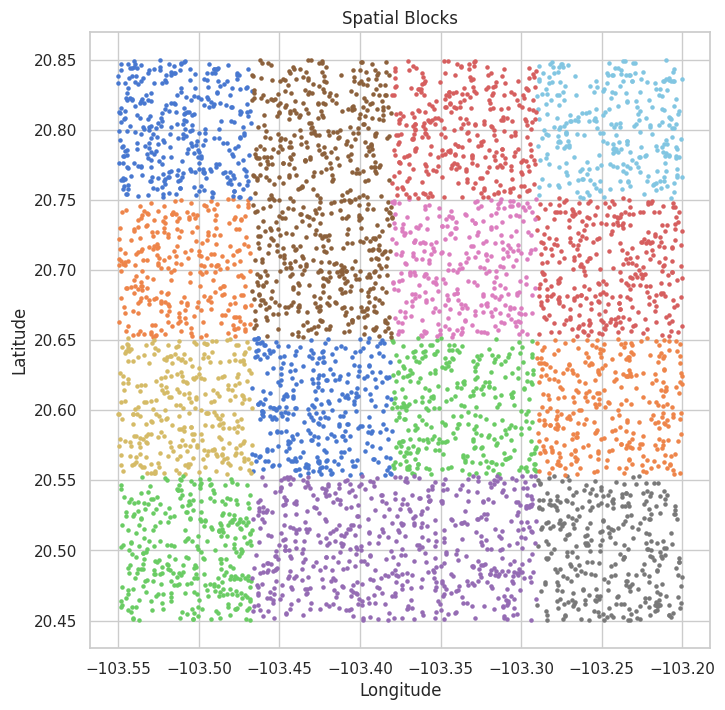

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for block in df["spatial_block"].unique():

    subset = df[df["spatial_block"] == block]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        s=5,
        label=block
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Blocks")
plt.show()

In [ ]:
coef_table = pd.DataFrame({
    "Variable"  : X.columns,
    "OLS"       : ols.coef_,
    "Ridge"     : ridge.coef_,
    "LASSO"     : lasso.coef_,
    "Elastic Net": elastic.coef_,
}).set_index("Variable").round(4)

print("Tabla comparativa de coeficientes (predictores estandarizados → y en °C):")
display(coef_table)


Tabla comparativa de coeficientes (predictores estandarizados → y en °C):


,OLS,Ridge,LASSO,Elastic Net
Variable,,,,
NDBI,0.0059,-0.0242,-0.0221,-0.0000
NDVI,-4.4425,-4.3844,-3.9993,-3.6559
NDWI,2.6086,2.4843,1.4299,1.5318
SAVI,7.5633,7.0829,3.5512,3.2000
SR_B2,1.0432,1.0396,0.8124,0.8006
SR_B3,-2.5400,-2.3788,-0.9635,-1.0934
SR_B4,4.0462,3.5507,-0.0000,-0.0000
SR_B5,-2.7851,-2.5233,-0.4124,-0.2117
SR_B6,0.1729,0.2138,-0.0000,-0.0000


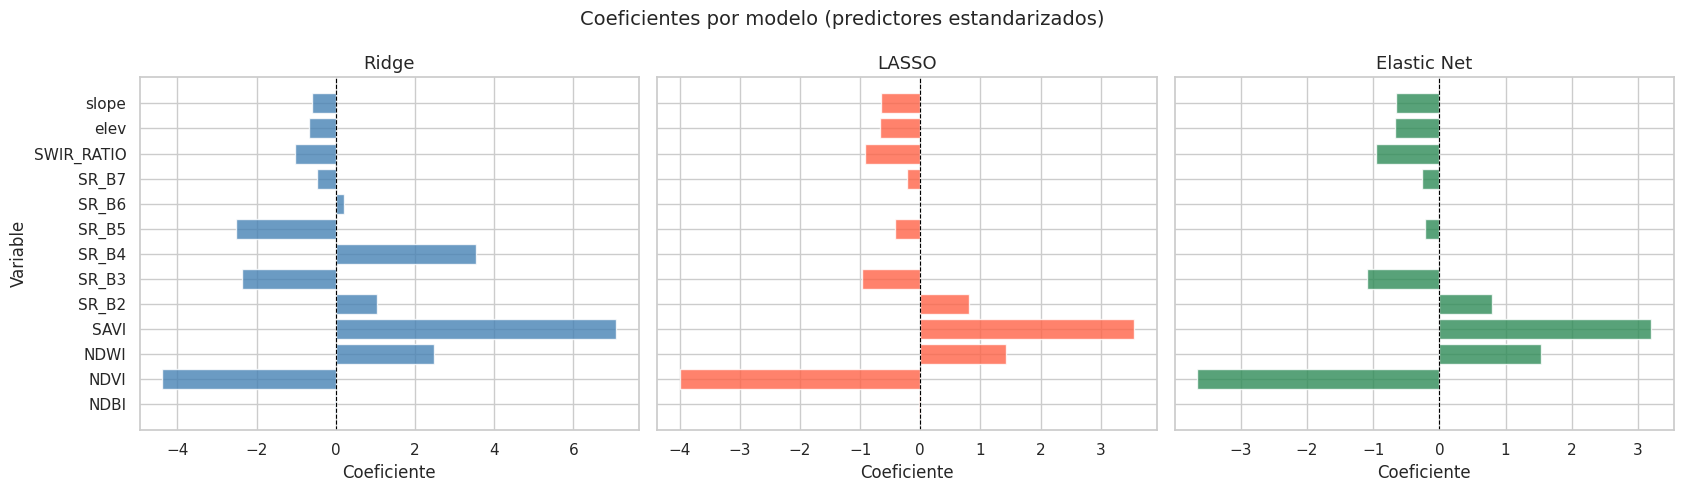

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
models_coefs = [
    ("Ridge",        ridge.coef_),
    ("LASSO",        lasso.coef_),
    ("Elastic Net",  elastic.coef_),
]
features = list(X.columns)
colors = ["steelblue", "tomato", "seagreen"]

for ax, (name, coef), col in zip(axes, models_coefs, colors):
    bars = ax.barh(features, coef, color=col, alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Coeficiente")

axes[0].set_ylabel("Variable")
plt.suptitle("Coeficientes por modelo (predictores estandarizados)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Hipótesis esperada (signos relativos a LST en Guadalajara)
hipotesis = {
    "NDVI"       : "negativo (vegetación → menor temperatura)",
    "NDWI"       : "negativo (humedad → menor temperatura)",
    "NDBI"       : "positivo (urbanización → mayor temperatura)",
    "SAVI"       : "negativo (similar a NDVI)",
    "SWIR_RATIO" : "sin hipótesis clara a priori",
    "SR_B2"      : "sin hipótesis directa",
    "SR_B3"      : "sin hipótesis directa",
    "SR_B4"      : "sin hipótesis directa",
    "SR_B5"      : "sin hipótesis directa",
    "SR_B6"      : "positivo (relacionado con NDBI)",
    "SR_B7"      : "sin hipótesis directa",
    "elev"       : "negativo (mayor altitud → menor temperatura)",
    "slope"      : "ambiguo",
}

obs = []
for var in X.columns:
    ols_s   = np.sign(ols.coef_[list(X.columns).index(var)])
    ridge_s = np.sign(ridge.coef_[list(X.columns).index(var)])
    lasso_s = np.sign(lasso.coef_[list(X.columns).index(var)])
    enet_s  = np.sign(elastic.coef_[list(X.columns).index(var)])
    obs.append({
        "Variable"        : var,
        "Hipótesis"       : hipotesis.get(var, "—"),
        "Signo OLS"       : ["−","0","+"][int(ols_s)+1],
        "Signo Ridge"     : ["−","0","+"][int(ridge_s)+1],
        "Signo LASSO"     : ["−","0","+"][int(lasso_s)+1],
        "Signo Enet"      : ["−","0","+"][int(enet_s)+1],
    })

hyp_df = pd.DataFrame(obs).set_index("Variable")
print("\nAnálisis de signo vs hipótesis geográfica:")
print("NOTA: inversión de signo puede deberse a colinealidad (por diseño),")
print("no necesariamente a un error del modelo.")
display(hyp_df)


Análisis de signo vs hipótesis geográfica:
NOTA: inversión de signo puede deberse a colinealidad (por diseño),
no necesariamente a un error del modelo.


,Hipótesis,Signo OLS,Signo Ridge,Signo LASSO,Signo Enet
Variable,,,,,
NDBI,positivo (urbanización → mayor temperatura),+,−,−,0
NDVI,negativo (vegetación → menor temperatura),−,−,−,−
NDWI,negativo (humedad → menor temperatura),+,+,+,+
SAVI,negativo (similar a NDVI),+,+,+,+
SR_B2,sin hipótesis directa,+,+,+,+
SR_B3,sin hipótesis directa,−,−,−,−
SR_B4,sin hipótesis directa,+,+,0,0
SR_B5,sin hipótesis directa,−,−,−,−
SR_B6,positivo (relacionado con NDBI),+,+,0,0


In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

feature_cols = list(X.columns)
target_col   = "LST"
blocks       = df["spatial_block"].unique()

spatial_results = []

for test_block in blocks:
    train_mask = df["spatial_block"] != test_block
    test_mask  = df["spatial_block"] == test_block

    X_tr = df.loc[train_mask, feature_cols].values
    y_tr = df.loc[train_mask, target_col].values
    X_te = df.loc[test_mask,  feature_cols].values
    y_te = df.loc[test_mask,  target_col].values

    if len(y_te) < 5:
        print(f"Bloque {test_block} muy pequeño ({len(y_te)} obs), omitido.")
        continue

    # Escalar SOLO con datos de entrenamiento (sin data leakage)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    en = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=20000,
        random_state=42,
        n_jobs=-1
    )
    en.fit(X_tr_s, y_tr)
    y_hat = en.predict(X_te_s)

    spatial_results.append({
        "Block"     : test_block,
        "n_test"    : len(y_te),
        "R²"        : round(r2_score(y_te, y_hat), 4),
        "RMSE"      : round(np.sqrt(mean_squared_error(y_te, y_hat)), 4),
        "MAE"       : round(np.mean(np.abs(y_te - y_hat)), 4),
        "Bias"      : round(np.mean(y_hat - y_te), 4),
        "# β ≠ 0"   : int(np.sum(en.coef_ != 0)),
    })

spatial_df = pd.DataFrame(spatial_results)
print("Validación espacial — Leave-One-Block-Out (Elastic Net):")
display(spatial_df)

print("\nPromedio entre bloques:")
display(spatial_df[["R²","RMSE","MAE","Bias"]].mean().round(4).to_frame("Media"))

Validación espacial — Leave-One-Block-Out (Elastic Net):


,Block,n_test,R²,RMSE,MAE,Bias,# β ≠ 0
0,1_1,320,0.4773,1.8976,1.5297,0.1658,11
1,0_2,281,0.7307,1.8493,1.5009,0.5312,12
2,2_1,316,0.3069,2.0779,1.5925,-0.4708,11
3,3_2,328,0.6777,2.2710,1.7204,0.5620,11
4,2_0,305,-0.2829,2.6832,2.2320,-1.6054,11
5,1_2,332,0.3072,2.0754,1.5496,0.1772,12
6,2_2,306,0.5885,2.2170,1.8176,-1.2501,11
7,3_0,322,0.0757,3.1153,2.4626,-1.7658,12
8,0_1,306,0.7445,1.8204,1.4116,0.2484,12
9,3_3,290,-0.3352,2.8635,2.4257,2.1210,12



Promedio entre bloques:


,Media
R²,0.3252
RMSE,2.2861
MAE,1.8130
Bias,0.0279


Comparación de estrategias de validación — Elastic Net
(La validación espacial es la estimación honesta de la capacidad de generalización)


,Aleatoria 70/30,Espacial LOBO (promedio)
Métrica,,
R²,0.6713,0.3252
RMSE (°C),2.2057,2.2861
MAE (°C),1.6930,1.8130
Bias (°C),-0.1435,0.0279


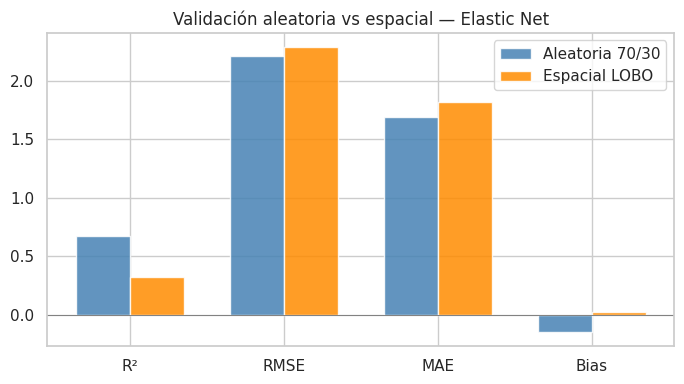

In [ ]:
# Métricas Elastic Net — validación aleatoria (ya calculada arriba)
rand_r2   = r2_score(y_test, y_pred_elastic)
rand_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
rand_mae  = np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred_elastic)))
rand_bias = np.mean(np.asarray(y_pred_elastic) - np.asarray(y_test))

comparison = pd.DataFrame({
    "Métrica"                  : ["R²", "RMSE (°C)", "MAE (°C)", "Bias (°C)"],
    "Aleatoria 70/30"          : [rand_r2, rand_rmse, rand_mae, rand_bias],
    "Espacial LOBO (promedio)" : [
        spatial_df["R²"].mean(),
        spatial_df["RMSE"].mean(),
        spatial_df["MAE"].mean(),
        spatial_df["Bias"].mean(),
    ],
})
comparison[["Aleatoria 70/30","Espacial LOBO (promedio)"]] = (
    comparison[["Aleatoria 70/30","Espacial LOBO (promedio)"]].round(4)
)
comparison = comparison.set_index("Métrica")

print("Comparación de estrategias de validación — Elastic Net")
print("(La validación espacial es la estimación honesta de la capacidad de generalización)")
display(comparison)

# Visualización comparativa
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ["R²", "RMSE", "MAE", "Bias"]
rand_vals   = [rand_r2, rand_rmse, rand_mae, rand_bias]
spatial_vals = [spatial_df["R²"].mean(), spatial_df["RMSE"].mean(),
                spatial_df["MAE"].mean(), spatial_df["Bias"].mean()]

x = np.arange(len(metrics))
w = 0.35
ax.bar(x - w/2, rand_vals,    w, label="Aleatoria 70/30",   color="steelblue",  alpha=0.85)
ax.bar(x + w/2, spatial_vals, w, label="Espacial LOBO",     color="darkorange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.axhline(0, color="gray", linewidth=0.7)
ax.set_title("Validación aleatoria vs espacial — Elastic Net")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import ElasticNetCV, LassoCV
import numpy as np

B             = 50
n_train       = X_train_scaled.shape[0]
feature_names = list(X.columns)
n_feat        = len(feature_names)

sel_enet  = np.zeros((B, n_feat))
sel_lasso = np.zeros((B, n_feat))

np.random.seed(42)
y_train_arr = np.asarray(y_train)

for b in range(B):
    idx   = np.random.choice(n_train, size=n_train, replace=True)
    X_b   = X_train_scaled[idx]
    y_b   = y_train_arr[idx]

    # LASSO (α = 1)
    lasso_b = LassoCV(cv=5, max_iter=20000, random_state=b)
    lasso_b.fit(X_b, y_b)
    sel_lasso[b] = (lasso_b.coef_ != 0).astype(int)

    # Elastic Net (α < 1)
    enet_b = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5, max_iter=20000, random_state=b
    )
    enet_b.fit(X_b, y_b)
    sel_enet[b] = (enet_b.coef_ != 0).astype(int)

pi_lasso = sel_lasso.mean(axis=0)
pi_enet  = sel_enet.mean(axis=0)

boot_df = pd.DataFrame({
    "Variable"           : feature_names,
    "π_j  LASSO (α=1)"  : pi_lasso,
    "π_j  Enet  (α<1)"  : pi_enet,
}).sort_values("π_j  Enet  (α<1)", ascending=False).reset_index(drop=True)

print(f"Bootstrap selection frequency (B={B} resamples):")
display(boot_df.round(3))
print("\nVariables estables (π_j ≥ 0.8) en Elastic Net:")
print(boot_df.loc[boot_df["π_j  Enet  (α<1)"] >= 0.8, "Variable"].tolist())

Bootstrap selection frequency (B=50 resamples):


,Variable,π_j LASSO (α=1),π_j Enet (α<1)
0,NDVI,1.00,1.00
1,SAVI,1.00,1.00
2,NDWI,1.00,1.00
3,SR_B2,1.00,1.00
4,SR_B3,1.00,1.00
5,elev,1.00,1.00
6,slope,1.00,1.00
7,SWIR_RATIO,1.00,1.00
8,NDBI,0.82,0.84
9,SR_B7,0.76,0.80



Variables estables (π_j ≥ 0.8) en Elastic Net:
['NDVI', 'SAVI', 'NDWI', 'SR_B2', 'SR_B3', 'elev', 'slope', 'SWIR_RATIO', 'NDBI', 'SR_B7']


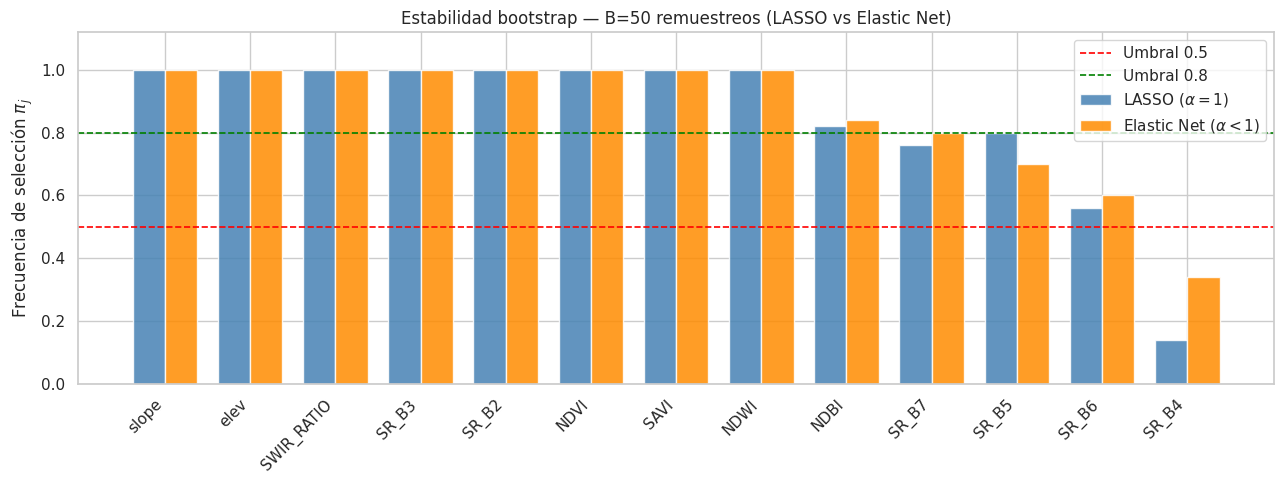

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

x   = np.arange(n_feat)
w   = 0.38
ord = np.argsort(pi_enet)[::-1]

ax.bar(x - w/2, pi_lasso[ord], w,
       label=r"LASSO ($\alpha=1$)",   color="steelblue",  alpha=0.85)
ax.bar(x + w/2, pi_enet[ord],  w,
       label=r"Elastic Net ($\alpha<1$)", color="darkorange", alpha=0.85)

ax.axhline(0.5,  color="red",  linestyle="--", linewidth=1.2, label="Umbral 0.5")
ax.axhline(0.8,  color="green",linestyle="--", linewidth=1.2, label="Umbral 0.8")
ax.set_xticks(x)
ax.set_xticklabels([feature_names[i] for i in ord], rotation=45, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel(r"Frecuencia de selección $\pi_j$")
ax.set_title(f"Estabilidad bootstrap — B={B} remuestreos (LASSO vs Elastic Net)")
ax.legend()
plt.tight_layout()
plt.show()
